In [1]:
import supervision as sv
from rfdetr import RFDETRMedium
from rfdetr.assets.coco_classes import COCO_CLASSES
import warnings
from PIL import Image
import cv2
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

/home/rakesh/venv_detection/lib/python3.12/site-packages/torch/cuda/__init__.py:68: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/rakesh/venv_detection/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [2]:
#mkdir -p /home/rakesh/.roboflow/models/
model = RFDETRMedium()

[2026-09-28 21:30:24] [INFO] rf-detr - File /home/rakesh/.roboflow/models/rf-detr-medium.pth already exists with correct MD5 hash.


[2026-09-28 21:30:24] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-28 21:30:24] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-09-28 21:30:25] [INFO] rf-detr - File /home/rakesh/.roboflow/models/rf-detr-medium.pth already exists with correct MD5 hash.


In [3]:
#detections = model.predict("https://media.roboflow.com/dog.jpg", threshold=0.5)
detections = model.predict("https://media.roboflow.com/dog.jpg", threshold=0.5, device="cpu")

[2026-09-28 21:30:26] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. For full GPU throughput (e.g. ~8x on T4 via FP16 Tensor Cores), call model.inference(dtype=torch.float16).


In [4]:
# 1. Generate the labels and apply annotations
labels = [f"{COCO_CLASSES[class_id]}" for class_id in detections.class_id]

annotated_image = sv.BoxAnnotator().annotate(detections.metadata["source_image"], detections)
annotated_image = sv.LabelAnnotator().annotate(annotated_image, detections, labels)

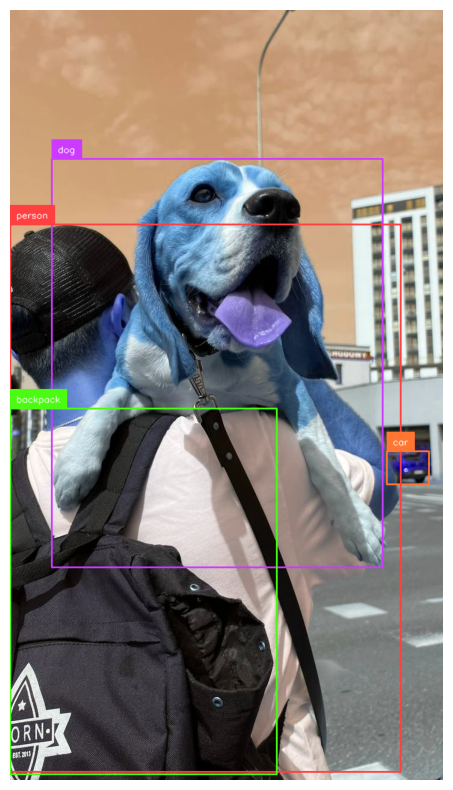

Annotated image successfully saved to /home/rakesh//Dropbox/CloudFin/Software/Security Surveillance/dog_annotated.jpg


In [5]:
# 2. Display the image
# Supervision / OpenCV uses BGR format, so we convert to RGB for Matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.axis("off")  # Hide grid lines and pixel axes
plt.show()

# 6. Save the output image locally
output_path = "/home/rakesh//Dropbox/CloudFin/Software/Security Surveillance/dog_annotated.jpg"
cv2.imwrite(output_path, annotated_image)
print(f"Annotated image successfully saved to {output_path}")

### Preapring COCO formatted dataset

In [14]:
import os
import urllib.request
import torch

# =====================================================================
# 1. MONKEY-PATCH TRANSFORMERS (Avoids AttributeError & Rust Compiler)
# =====================================================================
import transformers
from transformers import BertModel

def patched_get_extended_attention_mask(self, attention_mask, input_shape, device=None):
    if device is None:
        device = attention_mask.device
    if attention_mask.dim() == 2:
        extended_attention_mask = attention_mask[:, None, None, :]
    elif attention_mask.dim() == 3:
        extended_attention_mask = attention_mask[:, None, :, :]
    else:
        extended_attention_mask = attention_mask
    extended_attention_mask = extended_attention_mask.to(dtype=torch.float32)
    return (1.0 - extended_attention_mask) * -10000.0

def patched_invert_attention_mask(self, attention_mask):
    return (1.0 - attention_mask.to(dtype=torch.float32)) * -10000.0

def patched_get_head_mask(self, head_mask, num_hidden_layers, is_attention_chunked=False):
    if head_mask is not None:
        return head_mask
    return [None] * num_hidden_layers

# Inject the legacy functions back into the modern BertModel class
BertModel.get_extended_attention_mask = patched_get_extended_attention_mask
BertModel.invert_attention_mask = patched_invert_attention_mask
BertModel.get_head_mask = patched_get_head_mask

# =====================================================================
# 2. AUTODISTILL CACHE FIX 
# =====================================================================
CACHE_DIR = os.path.expanduser("~/.cache/autodistill/groundingdino")
CONFIG_PATH = os.path.join(CACHE_DIR, "GroundingDINO_SwinT_OGC.py")

if not os.path.exists(CONFIG_PATH):
    print("Fixing missing configuration file...")
    os.makedirs(CACHE_DIR, exist_ok=True)
    url = "https://githubusercontent.com"
    urllib.request.urlretrieve(url, CONFIG_PATH)
    print("Configuration file successfully restored!")

# =====================================================================
# 3. RUN AUTO-LABELING
# =====================================================================
from autodistill_grounding_dino import GroundingDINO
from autodistill.detection import CaptionOntology

DATASET_RAW_DIR = "dataset_raw/person_1" 
OUTPUT_DATASET_DIR = "./my_local_rfdetr_dataset"

ontology = CaptionOntology({
    "person": "person"
})

print("Initializing patched GroundingDINO...")
base_model = GroundingDINO(ontology=ontology)

print("Starting automatic labeling and COCO formatting...")
dataset = base_model.label(
    input_folder=DATASET_RAW_DIR,
    extension=".jpg",
    output_folder=OUTPUT_DATASET_DIR
)

print(f"\nSuccess! RF-DETR compatible dataset created at: {OUTPUT_DATASET_DIR}")

Initializing patched GroundingDINO...
trying to load grounding dino directly


torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4221.)


final text_encoder_type: bert-base-uncased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Starting automatic labeling and COCO formatting...


Labeling dataset_raw/person_1/person1_frame_0227.jpg:   0%|                                                                                                                                                                           | 0/294 [00:00<?, ?it/s][transformers] `use_return_dict` is deprecated! Use `return_dict` instead!
torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
None of the inputs have requires_grad=True. Gradients will be None
Labeling dataset_raw/person_1/person1_frame_0307.jpg: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 294/294

Found ./my_local_rfdetr_dataset/train/images/person1_frame_0227.jpg as already present, not moving anything to ./my_local_rfdetr_dataset/train/images
Found ./my_local_rfdetr_dataset/train/labels/person1_frame_0227.txt as already present, not moving anything to ./my_local_rfdetr_dataset/train/labels
Found ./my_local_rfdetr_dataset/train/images/person1_frame_0043.jpg as already present, not moving anything to ./my_local_rfdetr_dataset/train/images
Found ./my_local_rfdetr_dataset/train/labels/person1_frame_0043.txt as already present, not moving anything to ./my_local_rfdetr_dataset/train/labels
Found ./my_local_rfdetr_dataset/train/images/person1_frame_0220.jpg as already present, not moving anything to ./my_local_rfdetr_dataset/train/images
Found ./my_local_rfdetr_dataset/train/labels/person1_frame_0220.txt as already present, not moving anything to ./my_local_rfdetr_dataset/train/labels
Found ./my_local_rfdetr_dataset/train/images/person1_frame_0214.jpg as already present, not moving a

### Run the Local RF-DETR Training Loop

In [15]:
from rfdetr import RFDETRBase

# Initialize the model 
model = RFDETRBase()

# Start your local training loop forced on CPU
model.train(
    dataset_dir="./my_local_rfdetr_dataset",  
    epochs=50,                                 
    batch_size=2,          # Kept small (2 or 4) to prevent CPU system RAM bottlenecks                    
    output_dir="./runs/detect/train",
    # --- FORCE CPU CONFIGURATION ---
    device="cpu",          
    accelerator="cpu",     # Overrides the PyTorch Lightning automatic GPU discovery
)

[2026-09-28 01:39:19] [INFO] rf-detr - File /home/rakesh/.roboflow/models/rf-detr-base.pth already exists with correct MD5 hash.
[2026-09-28 01:39:20] [INFO] rf-detr - File /home/rakesh/.roboflow/models/rf-detr-base.pth already exists with correct MD5 hash.
[2026-09-28 01:39:21] [INFO] rf-detr - File /home/rakesh/.roboflow/models/rf-detr-base.pth already exists with correct MD5 hash.


[2026-09-28 01:39:22] [WARNING] rf-detr - Checkpoint has 90 classes but model is configured for 1. The detection head will be re-initialized to 1 classes.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[2026-09-28 01:39:22] [INFO] rf-detr - Using multi-scale training with square resize and scales: [840]
creating index...
index created!
[2026-09-28 01:39:22] [INFO] rf-detr - Using multi-scale training with square resize and scales: [840]
creating index...
index created!


ModuleNotFoundError: `MAP` metric requires that `pycocotools` or `faster-coco-eval` installed. Please install with `pip install pycocotools` or `pip install faster-coco-eval` or `pip install torchmetrics[detection]`.

### Real-Time Webcam Detection Script

##### Save this code as live_inference.py. You can run this as soon as your model finishes training.

In [17]:
import cv2
import time
import torch
import os
from rfdetr import RFDETRBase

# --- CONFIGURATION ---
# Path to the best weights generated by your training loop
#MODEL_WEIGHTS_PATH = "./runs/detect/train/weights/best.pth" 
INPUT_VIDEO_PATH = "/home/rakesh/Downloads/Data/Dataset Video/person_1_webcam.mp4"      # Path to your test video clip
OUTPUT_VIDEO_PATH = "/home/rakesh/Downloads/Data/Dataset Video/output_detection.mp4" # Where to save the finished video
MODEL_WEIGHTS_PATH = "./runs/detect/train/checkpoint_best_ema.pth"
CONFIDENCE_THRESHOLD = 0.5  
FRAME_WIDTH = 640
FRAME_HEIGHT = 480

# 1. Initialize and load custom weights directly in the constructor
print("Loading custom RF-DETR model weights...")
if not os.path.exists(MODEL_WEIGHTS_PATH):
    raise FileNotFoundError(f"Could not find model weights at: {MODEL_WEIGHTS_PATH}")

model = RFDETRBase(pretrain_weights=MODEL_WEIGHTS_PATH)
print("Model successfully initialized with custom weights!")

# 2. Open the input video file instead of a live webcam
cap = cv2.VideoCapture(INPUT_VIDEO_PATH)
if not cap.isOpened():
    raise FileNotFoundError(f"Error: Could not open input video file '{INPUT_VIDEO_PATH}'")

# Get input video properties for the exporter
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
if fps == 0: fps = 30.0 # Fallback default

# 3. Initialize the Video Writer to save output to disk
fourcc = cv2.VideoWriter_fourcc(*'mp4v') # Universal mp4 codec
out = cv2.VideoWriter(OUTPUT_VIDEO_PATH, fourcc, fps, (frame_width, frame_height))

print(f"Processing '{INPUT_VIDEO_PATH}'... Please wait.")
frame_count = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break # End of video file reached

    frame_count += 1
    start_time = time.time()
    
    # 4. Run RF-DETR inference on the current frame
    results = model.predict(frame, conf=CONFIDENCE_THRESHOLD)
    
    # 5. Parse detections and draw bounding boxes onto the frame
    if len(results) > 0 and hasattr(results, 'boxes'):
        boxes = results.boxes
        for box in boxes:
            x1, y1, x2, y2 = map(int, box.xyxy.tolist())
            confidence = float(box.conf)
            
            # Draw the bounding box (Green box)
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            
            # Create text label
            label = f"Person: {confidence:.2f}"
            cv2.putText(frame, label, (x1, max(y1 - 10, 20)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # Calculate processing latency per frame
    latency = (time.time() - start_time) * 1000
    if frame_count % 10 == 0:
        print(f"Processed frame {frame_count} | Processing Latency: {latency:.1f}ms")

    # 6. Write the processed frame directly to disk (No cv2.imshow)
    out.write(frame)

# Clean up resources silently without calling GUI features
cap.release()
out.release()
print(f"\nProcessing complete! Annotated video saved as: '{OUTPUT_VIDEO_PATH}'")

Loading custom RF-DETR model weights...


[2026-09-28 01:40:49] [WARNING] rf-detr - Checkpoint has 1 classes but model is configured for 90. Using checkpoint class count (1). Pass num_classes=1 to suppress this warning.
[2026-09-28 01:40:49] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. For full GPU throughput (e.g. ~8x on T4 via FP16 Tensor Cores), call model.inference(dtype=torch.float16).


Model successfully initialized with custom weights!
Processing '/home/rakesh/Downloads/Data/Dataset Video/person_1_webcam.mp4'... Please wait.
Processed frame 10 | Processing Latency: 101.7ms
Processed frame 20 | Processing Latency: 103.2ms
Processed frame 30 | Processing Latency: 106.6ms
Processed frame 40 | Processing Latency: 105.0ms
Processed frame 50 | Processing Latency: 103.9ms
Processed frame 60 | Processing Latency: 102.3ms
Processed frame 70 | Processing Latency: 102.1ms
Processed frame 80 | Processing Latency: 103.2ms
Processed frame 90 | Processing Latency: 101.0ms
Processed frame 100 | Processing Latency: 101.1ms
Processed frame 110 | Processing Latency: 101.9ms
Processed frame 120 | Processing Latency: 102.2ms
Processed frame 130 | Processing Latency: 102.2ms
Processed frame 140 | Processing Latency: 101.9ms
Processed frame 150 | Processing Latency: 101.7ms
Processed frame 160 | Processing Latency: 101.7ms
Processed frame 170 | Processing Latency: 102.0ms
Processed frame 